In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

print(tf.config.list_physical_devices('GPU'))
tf.random.set_seed(42)
np.random.seed(42)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
DATA_DIR = Path("data_processed")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 100
LEARNING_RATE = 1e-4

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_size = len(val_test_ds) // 2
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

CLASS_NAMES = train_ds.class_names
print(f"Classes: {CLASS_NAMES}")
print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}, Test batches: {len(test_ds)}")

Found 353 files belonging to 3 classes.
Using 283 files for training.
Found 353 files belonging to 3 classes.
Using 70 files for validation.
Classes: ['candy', 'chocolate', 'rice_snack']
Train batches: 36, Val batches: 4, Test batches: 5


2026-07-06 11:50:53.739808: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-07-06 11:50:53.739844: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-06 11:50:53.739852: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1783306253.739894 5114857 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1783306253.739951 5114857 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
factor = 0.2

augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(factor),
        tf.keras.layers.RandomZoom(factor),
        tf.keras.layers.RandomContrast(factor),
        tf.keras.layers.RandomTranslation(factor, factor),
    ]
)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [10]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        771 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/100


2026-07-06 11:50:55.715837: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.3640 - loss: 2.0958 - val_accuracy: 0.6250 - val_loss: 0.8516
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.4523 - loss: 1.6349 - val_accuracy: 0.5938 - val_loss: 0.9412
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.4982 - loss: 1.3929 - val_accuracy: 0.5625 - val_loss: 0.7450
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5336 - loss: 1.3992 - val_accuracy: 0.6875 - val_loss: 0.7805
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5689 - loss: 1.3379 - val_accuracy: 0.5312 - val_loss: 0.8577
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.5936 - loss: 1.0926 - val_accuracy: 0.4375 - val_loss: 0.9896
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6502 - loss: 1.1225 - val_accuracy: 0.5000 - val_loss: 0.9324
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.6466 - loss: 0.9814 - val_accuracy: 0.6250 - val

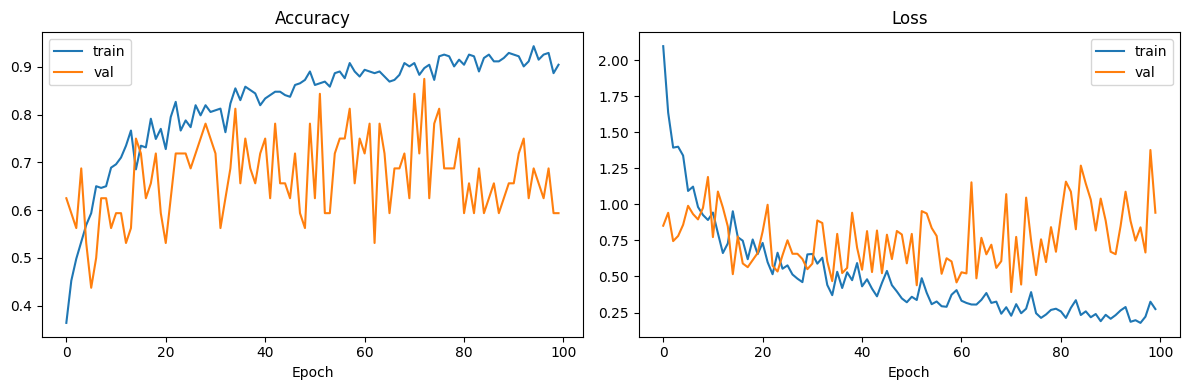

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["accuracy"], label="train")
ax1.plot(history.history["val_accuracy"], label="val")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["loss"], label="train")
ax2.plot(history.history["val_loss"], label="val")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

       candy       1.00      0.73      0.84        11
   chocolate       0.63      1.00      0.77        12
  rice_snack       0.91      0.67      0.77        15

    accuracy                           0.79        38
   macro avg       0.85      0.80      0.80        38
weighted avg       0.85      0.79      0.79        38



2026-07-06 11:55:23.700206: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
model.save('snack_classifier_epoch50.keras')
print(f"Model saved")

Model saved


In [16]:
def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0)
    predicted_class = CLASS_NAMES[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.1%})")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

# 使い方:
# predict_image("path/to/your/snack_image.jpg")